In [116]:
# thêm các thư viện và các hàm cần thiết vào

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report, auc, roc_curve, precision_recall_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder,MinMaxScaler,StandardScaler

from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [3]:
# thêm dataset vào 
data= pd.read_csv("./healthcare-dataset-stroke-data.csv")

In [5]:
# gọi ra 5 record đầu tiên của dataset
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
# kiểm tra xem dataset có những gì
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


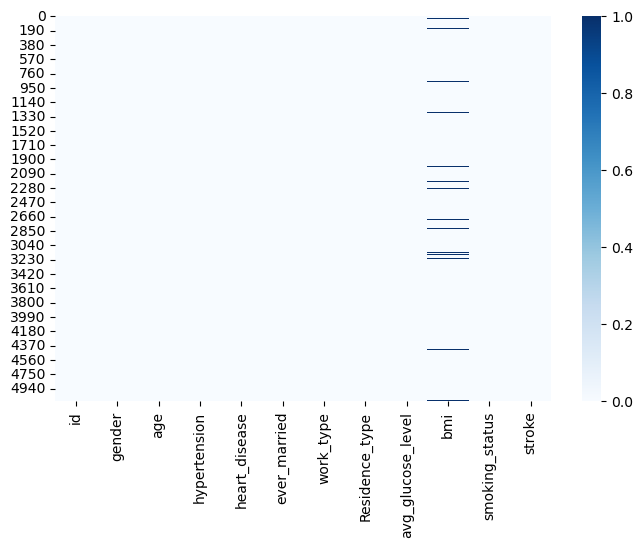

In [9]:
#dùng biểu đồ để trực quan hóa các DL còn thiếu
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(data.isna(), cmap="Blues");

# sử dụng biểu đồ để trực quan hóa dữ liệu
- 1.sử dụng biểu đồ tròn cho các trường DL có nhiều thuộc tính

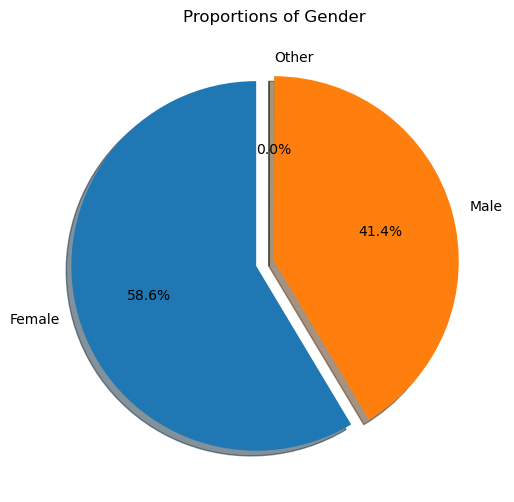

In [265]:


data_gender=data['gender']

count=data_gender.value_counts()
explode = [0.1 if i == 0 else 0 for i in range (len(count))]
plt.figure(figsize=(10,6))
plt.pie(count,labels=count.index,autopct='%1.1f%%', startangle=90,shadow=True,explode=explode)
plt.title('Proportions of Gender')
plt.show()

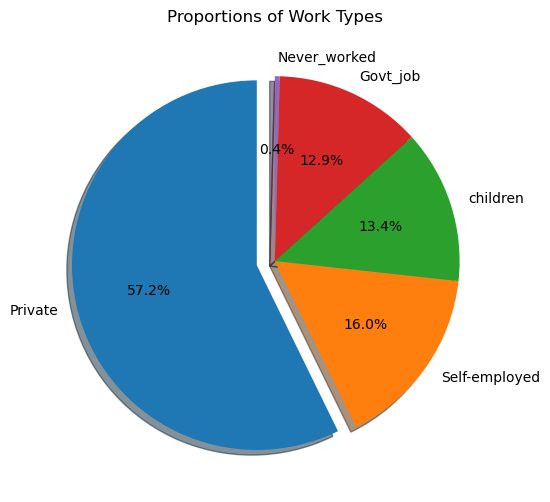

In [26]:
#1. khởi tạo biến 
data_worktype=data['work_type']

#2. đếm số lượng mỗi 
count=data_worktype.value_counts()
#3. tạo danh sách
explode = [0.1 if i == 0 else 0 for i in range (len(count))]
#4.Tạo biểu đồ tròn
plt.figure(figsize=(10,6))
plt.pie(count,labels=count.index,autopct='%1.1f%%', startangle=90,shadow=True,explode=explode)
plt.title('Proportions of Work Types')
plt.show()

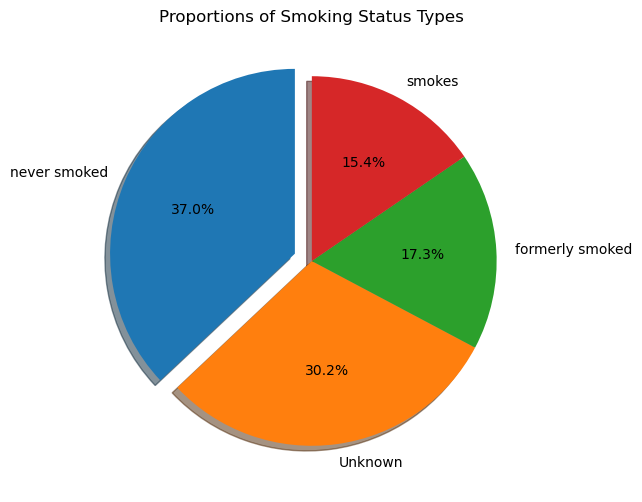

In [28]:
data_smoketype=data['smoking_status']

count=data_smoketype.value_counts()
explode = [0.1 if i == 0 else 0 for i in range (len(count))]
plt.figure(figsize=(10,6))
plt.pie(count,labels=count.index,autopct='%1.1f%%', startangle=90,shadow=True,explode=explode)
plt.title('Proportions of Smoking Status Types')
plt.show()

In [34]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,34.55,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1


# 2.biểu đồ cột 

In [37]:
data['hypertension'].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

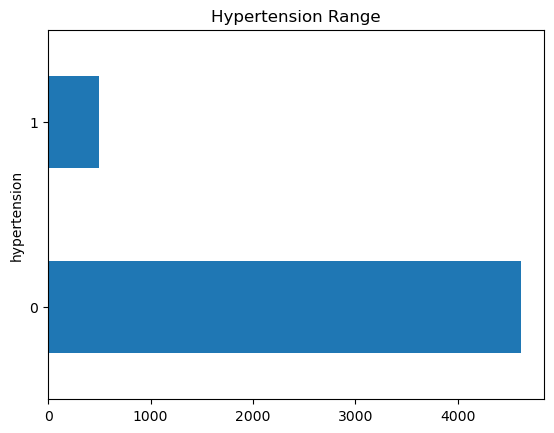

In [39]:
data['hypertension'].value_counts().plot(kind='barh')
plt.title("Hypertension Range")
plt.show()

In [41]:
data['ever_married'].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

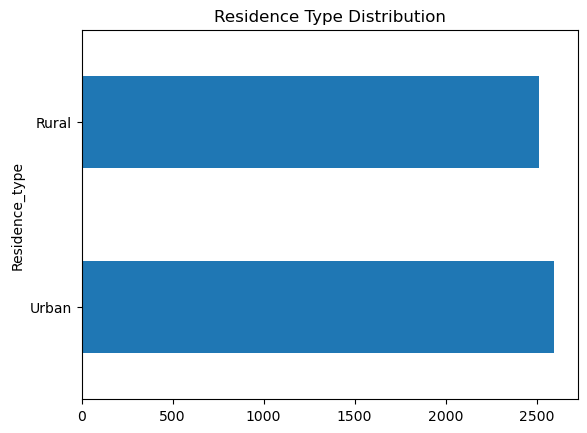

In [45]:
data['Residence_type'].value_counts().plot(kind='barh')
plt.title("Residence Type Distribution")
plt.show()

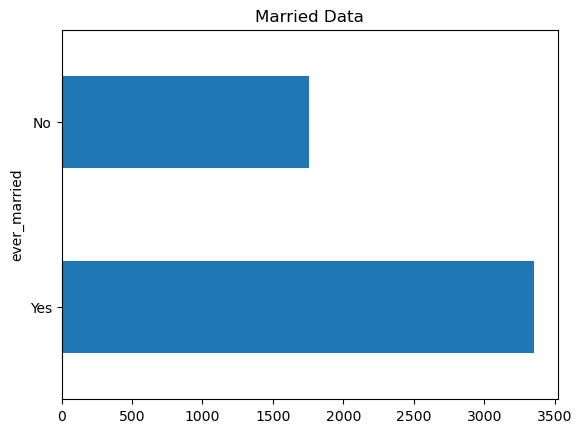

In [48]:
data['ever_married'].value_counts().plot(kind='barh')
plt.title("Married Data")
plt.show()

# 3. Biểu đồ mật độ

<Axes: xlabel='age', ylabel='Density'>

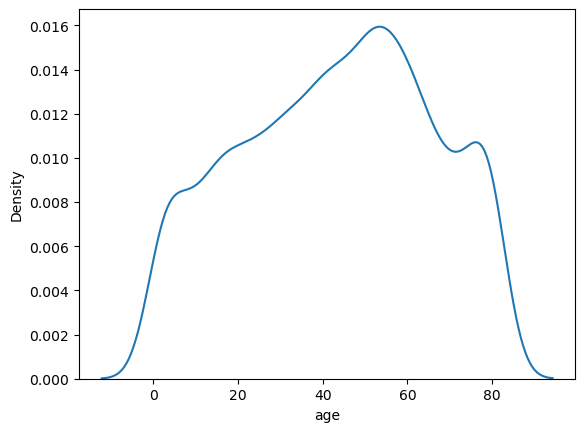

In [57]:
sns.kdeplot(data['age'])

In [312]:
data['avg_glucose_level'].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

In [63]:
data['age'].describe()


count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

<Axes: xlabel='avg_glucose_level', ylabel='Density'>

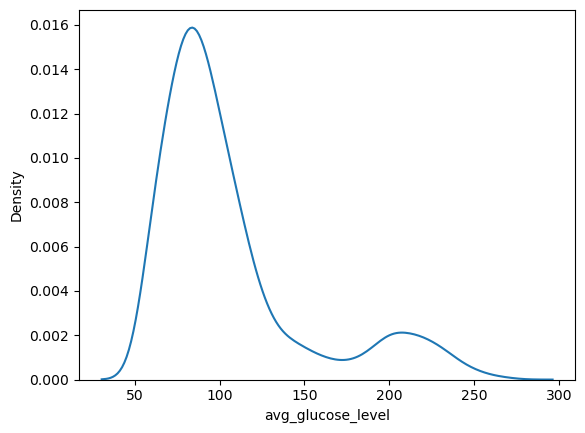

In [65]:
sns.kdeplot(data['avg_glucose_level'])

<Axes: xlabel='bmi', ylabel='Density'>

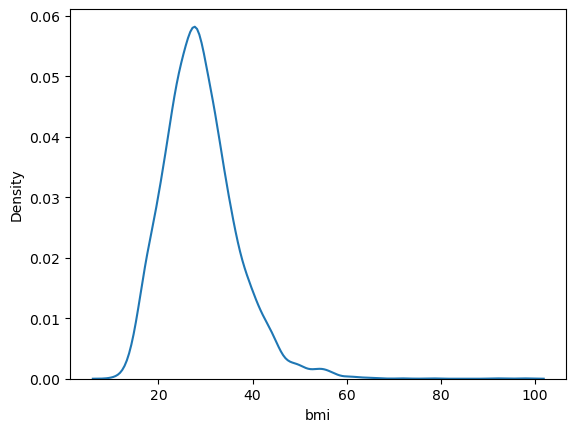

In [67]:
sns.kdeplot(data['bmi'])

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# Tiền xử lý dữ liệu

In [15]:
# Xóa các bản ghi có giá trị NaN trong cột 'bmi'
data = data.dropna(subset=['bmi'])


In [17]:
# xóa thuộc tính Unknow trong cột  smoking_tatus
data = data[data['smoking_status'] != 'Unknown']

In [19]:
# xóa thuộc tính other : 2 trong cột gender
data = data[data['gender']!='Other']

In [21]:
# Xóa các giá trị số thực trong cột 'tuổi'  
data = data[data['age'].apply(lambda x: x.is_integer())]  
# Chuyển kiểu dữ liệu của cột 'tuổi' từ float64 sang int64  
data['age'] = data['age'].astype('int64')

In [23]:
data['ever_married'] = data['ever_married'].replace({'No':0,'Yes':1})
data['work_type'] = data['work_type'].replace({'children':0,'Govt_job':1 ,'Private':2,'Self-employed':3, 'Never_worked':4})
data['Residence_type'] = data['Residence_type'].replace({'Rural':0 , 'Urban':1})
data['smoking_status'] = data['smoking_status'].replace({ 'never smoked':1, 'formerly smoked':2 , 'smokes':3})
                                                     

In [25]:
data['gender'] = data['gender'].replace({'Female': 0, 'Male': 1})
data = data.infer_objects(copy=False)

In [27]:
# xóa DL cột id ( vì ko quá cần thiết)
data=data.drop('id', axis=1)

In [277]:
data.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.60,2,1
1,0,61.0,0,0,1,3,0,202.21,34.55,1,1
2,1,80.0,0,1,1,2,0,105.92,32.50,1,1
3,0,49.0,0,0,1,2,1,171.23,34.40,3,1
4,0,79.0,1,0,1,3,0,174.12,24.00,1,1
5,1,81.0,0,0,1,2,1,186.21,29.00,2,1
6,1,74.0,1,1,1,2,0,70.09,27.40,1,1
7,0,69.0,0,0,0,2,1,94.39,22.80,1,1
8,0,59.0,0,0,1,2,0,76.15,23.50,0,1
9,0,78.0,0,0,1,2,1,58.57,24.20,0,1


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3425 entries, 0 to 5108
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3425 non-null   int64  
 1   age                3425 non-null   int64  
 2   hypertension       3425 non-null   int64  
 3   heart_disease      3425 non-null   int64  
 4   ever_married       3425 non-null   int64  
 5   work_type          3425 non-null   int64  
 6   Residence_type     3425 non-null   int64  
 7   avg_glucose_level  3425 non-null   float64
 8   bmi                3425 non-null   float64
 9   smoking_status     3425 non-null   int64  
 10  stroke             3425 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 321.1 KB


In [52]:
# kiểm tra kiểu dữ liệu của các cột trước khi tính ma trận tương quan
print(data.dtypes)

gender                 int64
age                    int64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object


In [33]:
#Khi bạn gọi df.corr(), bạn sẽ nhận được một ma trận tương quan, trong đó mỗi ô cho biết độ tương quan giữa hai cột. Độ tương quan có giá trị trong khoảng từ -1 đến 1:

#1: Tương quan dương hoàn hảo (khi một biến tăng, biến còn lại cũng tăng).
#0: Không có tương quan.
#-1: Tương quan âm hoàn hảo (khi một biến tăng, biến còn lại giảm).


correlation_matrix = data.select_dtypes(include=['float64', 'int64']).corr()
print(correlation_matrix)

                     gender       age  hypertension  heart_disease  \
gender             1.000000  0.044580      0.037853       0.101834   
age                0.044580  1.000000      0.267030       0.260077   
hypertension       0.037853  0.267030      1.000000       0.111683   
heart_disease      0.101834  0.260077      0.111683       1.000000   
ever_married       0.018076  0.523017      0.116716       0.076589   
work_type         -0.027150  0.242185      0.066245       0.042309   
Residence_type    -0.013412  0.015472     -0.003374       0.009937   
avg_glucose_level  0.070169  0.233974      0.168769       0.143152   
bmi                0.014284  0.079317      0.132544       0.001208   
smoking_status     0.073409  0.054104     -0.001316       0.062549   
stroke             0.012413  0.242465      0.143626       0.138538   

                   ever_married  work_type  Residence_type  avg_glucose_level  \
gender                 0.018076  -0.027150       -0.013412           0.070169 

<Axes: >

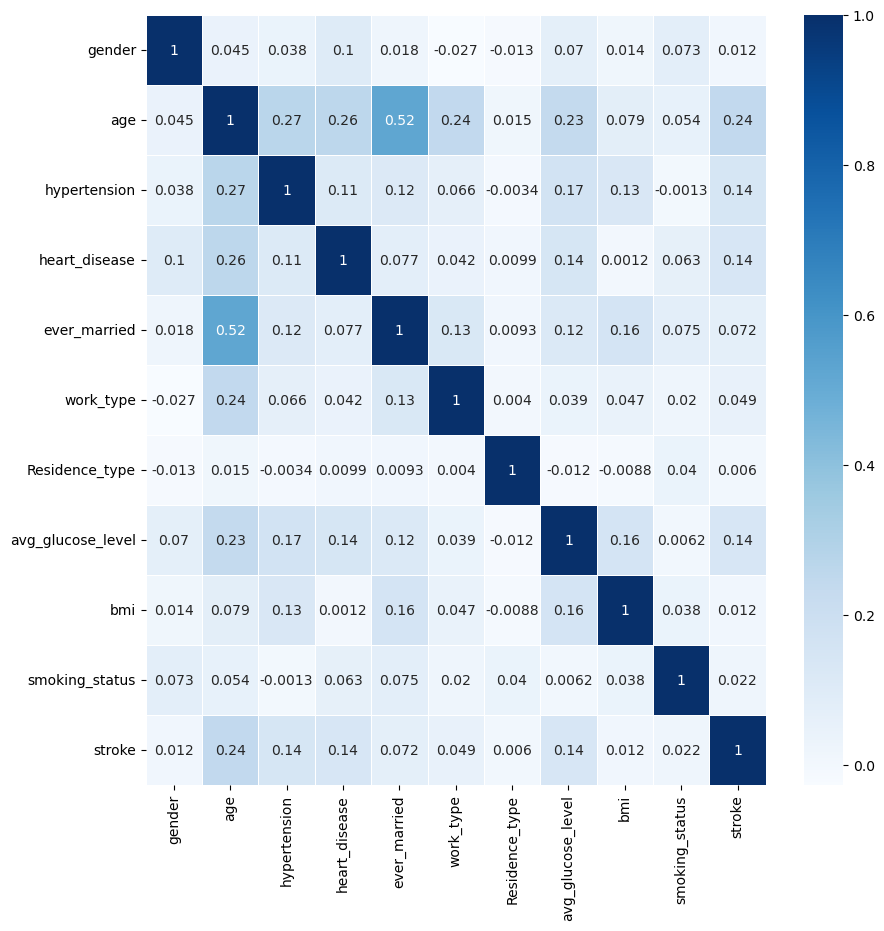

In [54]:
# sử dụng biểu đồ heatmap 
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(), annot=True, cmap='Blues',linewidths=0.5 )

In [56]:
# gán x = toàn bộ DL của các cột trong dataset trừ  cột stroke
# gán y =  toàn bộ DL cột  stroke
x = data.drop('stroke',axis=1)
y = data['stroke']

In [58]:
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67,0,1,1,2,1,228.69,36.6,2
2,1,80,0,1,1,2,0,105.92,32.5,1
3,0,49,0,0,1,2,1,171.23,34.4,3
4,0,79,1,0,1,3,0,174.12,24.0,1
5,1,81,0,0,1,2,1,186.21,29.0,2
...,...,...,...,...,...,...,...,...,...,...
5100,1,82,1,0,1,3,0,71.97,28.3,1
5102,0,57,0,0,1,2,0,77.93,21.7,1
5106,0,81,0,0,1,3,1,125.20,40.0,1
5107,0,35,0,0,1,3,0,82.99,30.6,1


 # Xử lý dữ liệu mất cân bằng bằng kỹ thuật SMOTE 

In [60]:
smote = SMOTE(k_neighbors=5)
x_oversampled,y_oversampled=smote.fit_resample(x,y)

In [62]:
x_oversampled

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67,0,1,1,2,1,228.690000,36.600000,2
1,1,80,0,1,1,2,0,105.920000,32.500000,1
2,0,49,0,0,1,2,1,171.230000,34.400000,3
3,0,79,1,0,1,3,0,174.120000,24.000000,1
4,1,81,0,0,1,2,1,186.210000,29.000000,2
...,...,...,...,...,...,...,...,...,...,...
6485,1,62,0,0,1,3,0,116.821454,34.598100,2
6486,0,81,0,0,1,2,0,73.601769,25.449340,1
6487,0,77,0,0,1,2,0,125.884688,28.760469,1
6488,0,77,0,0,1,2,0,233.624281,34.566906,1


# chia dữ liệu thành tập trainning và tập testting

In [64]:
x_train ,x_test, y_train ,y_test = train_test_split(x_oversampled , y_oversampled, test_size=0.20)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5192, 10)
(1298, 10)
(5192,)
(1298,)


In [66]:
x_train

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
5089,0,80,0,0,1,2,0,75.264862,22.283716,1
3604,0,81,0,0,1,2,0,87.055626,29.822209,1
5440,0,60,0,0,0,2,1,90.363763,36.995130,1
4453,0,68,0,0,0,3,1,77.825873,27.506559,2
3765,0,78,0,1,1,2,0,227.774967,31.032372,1
...,...,...,...,...,...,...,...,...,...,...
1155,0,50,0,0,1,3,1,85.920000,37.300000,3
4185,0,49,0,0,1,2,0,168.050132,31.486508,1
4346,0,81,0,0,1,1,1,200.568981,28.971974,2
1266,0,45,0,0,1,2,1,115.230000,28.000000,1


In [68]:
y_train

5089    1
3604    1
5440    1
4453    1
3765    1
       ..
1155    0
4185    1
4346    1
1266    0
1930    0
Name: stroke, Length: 5192, dtype: int64

# LogisticRegression (hồi quy )

In [70]:
#LogisticRegression (hồi quy ) -> dùng để phân loại dự đoán
# khởi tạo và huấn luyện mô hình
lg_model = LogisticRegression()
lg_model.fit(x_train,y_train)

LogisticRegression()

In [76]:
# đánh giá mô hình trên tập dữ liệu train
y_pred_train = lg_model.predict(x_train)
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data:{accuracy_score(y_train,y_pred_train):.4f}")

Confusion Matrix:
 [[2036  569]
 [ 516 2071]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79      2605
           1       0.78      0.80      0.79      2587

    accuracy                           0.79      5192
   macro avg       0.79      0.79      0.79      5192
weighted avg       0.79      0.79      0.79      5192


Accuracy on Train data:0.7910


In [78]:
# Đánh giá mô hình trên dữ liệu thử nghiệm
y_pred_test = lg_model.predict(x_test)
#In ma trận nhầm lẫn để so sánh nhãn thực tế và nhãn dự đoán.
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()

#In báo cáo phân loại để cung cấp thông tin chi tiết về hiệu suất của mô hình. 
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()

#In độ chính xác của mô hình trên tập kiểm tra.

print(f"Accuracy on Test data:{accuracy_score(y_test,y_pred_test):.4f}")

Confusion Matrix:
 [[491 149]
 [149 509]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77       640
           1       0.77      0.77      0.77       658

    accuracy                           0.77      1298
   macro avg       0.77      0.77      0.77      1298
weighted avg       0.77      0.77      0.77      1298


Accuracy on Test data:0.7704


# sử dụng thuật toán KNN để huấn luyện và đánh giá mô hình


In [82]:
#Khởi tạo và huấn luyện mô hình KNN:

knn_model = KNeighborsClassifier()
knn_model.fit(x_train,y_train)

#Dự đoán trên tập train
y_pred_train = knn_model.predict(x_train)
print("---KNN Model evaluation on Train data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data:{accuracy_score(y_train,y_pred_train):.4f}")

---KNN Model evaluation on Train data---

Confusion Matrix:
 [[2168  437]
 [  31 2556]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.83      0.90      2605
           1       0.85      0.99      0.92      2587

    accuracy                           0.91      5192
   macro avg       0.92      0.91      0.91      5192
weighted avg       0.92      0.91      0.91      5192


Accuracy on Train data:0.9099


In [84]:
#Dự đoán trên tập kiểm tra:
y_pred_test = knn_model.predict(x_test)

print("---KNN Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for KNN Model:{accuracy_score(y_test,y_pred_test):.4f}")

---KNN Model Evaluation On Test Data---

Confusion Matrix:
 [[497 143]
 [ 17 641]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.78      0.86       640
           1       0.82      0.97      0.89       658

    accuracy                           0.88      1298
   macro avg       0.89      0.88      0.88      1298
weighted avg       0.89      0.88      0.88      1298


Accuracy on Test data for KNN Model:0.8767


In [ ]:
# Hyperparameter Tuning for KNN (điều chỉnh siêu tham số cho KNN ) -->giảm overfiting

In [86]:
# 1.khởi tạo mô hình KNN
knn_model_1= KNeighborsClassifier()

# 2.Định nghĩa lưới tham số
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance'] }

#3.Khởi tạo RandomizedSearchCV
rscv_knn_model = GridSearchCV(knn_model_1, param_grid, cv=5)

#4.Huấn luyện mô hình với tìm kiếm ngẫu nhiên
rscv_knn_model .fit(x_train, y_train)

#5.Xem siêu tham số tốt nhất
rscv_knn_model.best_estimator_

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [90]:
#1.Lấy mô hình tốt nhất từ tìm kiếm siêu tham số
new_knn_model = rscv_knn_model.best_estimator_

#2.Dự đoán trên tập kiểm tra:
y_pred_test = new_knn_model.predict(x_test)

#3.Đánh giá mô hình
print("---KNN Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for KNN Model:{accuracy_score(y_test,y_pred_test):.4f}")

---KNN Model Evaluation On Test Data---

Confusion Matrix:
 [[507 133]
 [  5 653]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.79      0.88       640
           1       0.83      0.99      0.90       658

    accuracy                           0.89      1298
   macro avg       0.91      0.89      0.89      1298
weighted avg       0.91      0.89      0.89      1298


Accuracy on Test data for KNN Model:0.8937


In [92]:
# dự đoán trên tập train
y_pred_train = new_knn_model.predict(x_train)

#3.Đánh giá mô hình
print("---KNN Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Test data for KNN Model:{accuracy_score(y_train,y_pred_train):.4f}")

---KNN Model Evaluation On Test Data---

Confusion Matrix:
 [[2605    0]
 [   0 2587]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2605
           1       1.00      1.00      1.00      2587

    accuracy                           1.00      5192
   macro avg       1.00      1.00      1.00      5192
weighted avg       1.00      1.00      1.00      5192


Accuracy on Test data for KNN Model:1.0000


# Random Forest Tree

In [96]:

# khởi tạo và huấn luyện mô 
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

#Dự đoán trên tập kiểm tra:
y_pred_test = rf_model.predict(x_test)

print("---RandomForest Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for RandomForest Model:{accuracy_score(y_test,y_pred_test):.4f}")

---RandomForest Model Evaluation On Test Data---

Confusion Matrix:
 [[583  57]
 [ 30 628]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       640
           1       0.92      0.95      0.94       658

    accuracy                           0.93      1298
   macro avg       0.93      0.93      0.93      1298
weighted avg       0.93      0.93      0.93      1298


Accuracy on Test data for RandomForest Model:0.9330


In [98]:
#Dự đoán trên tập train:

y_pred_train = rf_model.predict(x_train)
print("---RandomForest Model evaluation on Train data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data for RandomForest Model:{accuracy_score(y_train,y_pred_train):.4f}")

---RandomForest Model evaluation on Train data---

Confusion Matrix:
 [[2605    0]
 [   0 2587]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2605
           1       1.00      1.00      1.00      2587

    accuracy                           1.00      5192
   macro avg       1.00      1.00      1.00      5192
weighted avg       1.00      1.00      1.00      5192


Accuracy on Train data for RandomForest Model:1.0000


# Hyperparameter Tunning(Điều chỉnh siêu tham số) 
# -->để giảm thiểu tình trạng overfitting cho mô hình Random Forest

In [101]:
#1.Khởi tạo mô hình Random Forest
rf_model_1 = RandomForestClassifier()

#2.Định nghĩa lưới tham số
param_grid ={'n_estimators':np.arange(50,200),
    'criterion':['gini','entropy'],
    'max_depth':np.arange(2,25),
    'min_samples_split':np.arange(2,25),
    'min_samples_leaf':np.arange(2,25)}

#3.Khởi tạo RandomizedSearchCV
rscv_rf_model = RandomizedSearchCV(rf_model_1,param_grid, cv=5)

#4.Huấn luyện mô hình với tìm kiếm ngẫu nhiên
rscv_rf_model.fit(x_train,y_train)

#5.Xem siêu tham số tốt nhất
rscv_rf_model.best_estimator_

RandomForestClassifier(max_depth=21, min_samples_leaf=5, min_samples_split=14,
                       n_estimators=59)

In [105]:
#1.Lấy mô hình tốt nhất từ tìm kiếm siêu tham số
new_rf_model = rscv_rf_model.best_estimator_

#2.Dự đoán trên tập kiểm tra
y_pred_test = new_rf_model.predict(x_test)

#3.Đánh giá mô hình
print("---RandomForest Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for RandomForest Model:{accuracy_score(y_test,y_pred_test):.4f}")

---RandomForest Model Evaluation On Test Data---

Confusion Matrix:
 [[553  87]
 [ 42 616]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.86      0.90       640
           1       0.88      0.94      0.91       658

    accuracy                           0.90      1298
   macro avg       0.90      0.90      0.90      1298
weighted avg       0.90      0.90      0.90      1298


Accuracy on Test data for RandomForest Model:0.9006


In [107]:
#2.Dự đoán trên tập train

y_pred_train = new_rf_model.predict(x_train)
print("---RandomForest Model evaluation on Train data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data for RandomForest Model:{accuracy_score(y_train,y_pred_train):.4f}")

---RandomForest Model evaluation on Train data---

Confusion Matrix:
 [[2407  198]
 [  98 2489]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94      2605
           1       0.93      0.96      0.94      2587

    accuracy                           0.94      5192
   macro avg       0.94      0.94      0.94      5192
weighted avg       0.94      0.94      0.94      5192


Accuracy on Train data for RandomForest Model:0.9430


# sử dụng mô hình AdaBoost để huấn luyện và đánh giá mô hình

In [109]:
#1.Khởi tạo và huấn luyện mô hình AdaBoost

ab_model = AdaBoostClassifier()
ab_model.fit(x_train, y_train)

#2.Dự đoán trên tập kiểm tra

y_pred_test = ab_model.predict(x_test)

#3.Đánh giá mô hình

print("---Adaboost Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for Adaboost Model:{accuracy_score(y_test,y_pred_test):.4f}")

---Adaboost Model Evaluation On Test Data---

Confusion Matrix:
 [[502 138]
 [115 543]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.80       640
           1       0.80      0.83      0.81       658

    accuracy                           0.81      1298
   macro avg       0.81      0.80      0.80      1298
weighted avg       0.81      0.81      0.80      1298


Accuracy on Test data for Adaboost Model:0.8051


In [111]:
# dự đoán trên tập train
y_pred_train = ab_model.predict(x_train)
print("---Adaboost Model evaluation on Train data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data for Adaboost Model:{accuracy_score(y_train,y_pred_train):.4f}")

---Adaboost Model evaluation on Train data---

Confusion Matrix:
 [[2060  545]
 [ 375 2212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82      2605
           1       0.80      0.86      0.83      2587

    accuracy                           0.82      5192
   macro avg       0.82      0.82      0.82      5192
weighted avg       0.82      0.82      0.82      5192


Accuracy on Train data for Adaboost Model:0.8228


In [ ]:
# Hyperparameter Tuning for Adaboost (điều chỉnh siêu tham số cho Adaboost )

In [113]:
#1.Khởi tạo mô hình AdaBoost
ab_model_1=AdaBoostClassifier()

#2.Định nghĩa lưới tham số (param_grid)
param_grid={"n_estimators":np.arange(50,200),
           "learning_rate":np.arange(0,2,0.001)}
#3.Khởi tạo RandomizedSearchCV
rscv_new1_model=RandomizedSearchCV(ab_model_1,param_grid,cv=5)

#4.Huấn luyện mô hình với tìm kiếm ngẫu nhiên
rscv_new1_model.fit(x_train,y_train)
#5. Xem siêu tham số tốt nhất
rscv_new1_model.best_estimator_

AdaBoostClassifier(learning_rate=1.867, n_estimators=162)

In [115]:
#1.Lấy mô hình tốt nhất từ tìm kiếm siêu tham số
new_ab_model = rscv_new1_model.best_estimator_

#2.Dự đoán trên tập kiểm tra
y_pred_test = new_ab_model.predict(x_test)

#3.Đánh giá mô hình
print("---Adaboost Model Evaluation On Test Data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_test))
print()
print("Classification Report:\n",classification_report(y_test, y_pred_test))
print()
print(f"Accuracy on Test data for Adaboost Model:{accuracy_score(y_test,y_pred_test):.4f}")

---Adaboost Model Evaluation On Test Data---

Confusion Matrix:
 [[504 136]
 [114 544]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80       640
           1       0.80      0.83      0.81       658

    accuracy                           0.81      1298
   macro avg       0.81      0.81      0.81      1298
weighted avg       0.81      0.81      0.81      1298


Accuracy on Test data for Adaboost Model:0.8074


In [117]:
# dự đoán trên tập train
y_pred_train = new_ab_model.predict(x_train)
print("---Adaboost Model evaluation on Train data---")
print()
print("Confusion Matrix:\n",confusion_matrix(y_train, y_pred_train))
print()
print("Classification Report:\n",classification_report(y_train, y_pred_train))
print()
print(f"Accuracy on Train data for Adaboost Model:{accuracy_score(y_train,y_pred_train):.4f}")

---Adaboost Model evaluation on Train data---

Confusion Matrix:
 [[2125  480]
 [ 366 2221]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      2605
           1       0.82      0.86      0.84      2587

    accuracy                           0.84      5192
   macro avg       0.84      0.84      0.84      5192
weighted avg       0.84      0.84      0.84      5192


Accuracy on Train data for Adaboost Model:0.8371


In [121]:
# Lưu mô hình RandomForestTree với siêu tham số đã huấn luyện 
joblib.dump(new_rf_model,'Stroke_Diagnosis_model.pkl')

['Stroke_Diagnosis_model.pkl']

In [135]:
import tkinter as tk
from tkinter import messagebox
import pandas as pd
import joblib

# Tải mô hình
model = joblib.load("Stroke_Diagnosis_model.pkl")

def submit():
    try:
        # Lấy dữ liệu từ các ô nhập
        gender = int(gender_entry.get())
        age = float(age_entry.get())
        hypertension = int(hypertension_entry.get())
        heart_disease = int(heart_disease_entry.get())
        ever_married = int(ever_married_entry.get())
        work_type = int(work_type_entry.get())
        residence_type = int(residence_type_entry.get())
        avg_glucose_level = float(avg_glucose_entry.get())
        bmi = float(bmi_entry.get())
        smoking_status = int(smoking_status_entry.get())
        
        # Chuyển đổi dữ liệu thành DataFrame
        input_data = pd.DataFrame({
            'gender': [gender],
            'age': [age],
            'hypertension': [hypertension],
            'heart_disease': [heart_disease],
            'ever_married': [ever_married],
            'work_type': [work_type],
            'Residence_type': [residence_type],
            'avg_glucose_level': [avg_glucose_level],
            'bmi': [bmi],
            'smoking_status': [smoking_status]
        })

        # Dự đoán
        prediction = model.predict(input_data)

        # Hiển thị kết quả
        if prediction[0] == 1:
            messagebox.showinfo("Kết quả", "Người này có nguy cơ bị đột quỵ!")
        else:
            messagebox.showinfo("Kết quả", "Người này không có nguy cơ bị đột quỵ!")
    
    except ValueError:
        messagebox.showerror("Lỗi", "Vui lòng nhập đúng định dạng cho tất cả các trường!")
    except Exception as e:
        messagebox.showerror("Lỗi", f"Đã xảy ra lỗi: {str(e)}")

# Tạo cửa sổ chính
root = tk.Tk()
root.title("Chẩn Đoán Người Mắc Bệnh Đột Quỵ")
root.geometry("600x800")  # width x heigh
root.configure(bg="#f2f2f2")  # Màu nền

# Thêm tiêu đề
title_label = tk.Label(root, text="Chẩn Đoán Bệnh Đột Quỵ", font=("Helvetica", 16, "bold"), bg="#f2f2f2")
title_label.pack(pady=20)

# Thêm các ô nhập với padding
inputs = [
    ("Giới tính (0: Nam, 1: Nữ):", "gender"),
    ("Tuổi:", "age"),
    ("Bệnh cao huyết áp (0: Không, 1: Có):", "hypertension"),
    ("Bệnh tim (0: Không, 1: Có):", "heart_disease"),
    ("Tình trạng hôn nhân (0: Không, 1: Có):", "ever_married"),
    ("Loại hình công việc ('children':0,'Govt_job':1 ,'Private':2,'Self-employed':3, 'Never_worked':4):", "work_type"),
    ("Nơi cư trú (0: Nông thôn, 1: Thành phố):", "residence_type"),
    ("Mức glucose trung bình:", "avg_glucose"),
    ("Chỉ số BMI:", "bmi"),
    ("Tình trạng thuốc lá ('never smoked':1, 'formerly smoked':2 , 'smokes':3):", "smoking_status")
]

# Tạo các ô nhập
for label_text, entry_var in inputs:
    tk.Label(root, text=label_text, bg="#f2f2f2").pack(pady=5)
    entry = tk.Entry(root)
    entry.pack(pady=5)
    globals()[f"{entry_var}_entry"] = entry

# Nút gửi dữ liệu
submit_button = tk.Button(root, text="Chẩn Đoán", command=submit, bg="#4CAF50", fg="white", font=("Helvetica", 12))
submit_button.pack(pady=20)

# Bắt đầu vòng lặp chính
root.mainloop()


array([0], dtype=int64)

In [133]:
# import tkinter as tk
# from tkinter import messagebox
# import pandas as pd
# import joblib

# # Tải mô hình
# model = joblib.load("stroke_diagnosis_model.pkl")

# def submit():
#     try:
#         # Lấy dữ liệu từ các ô nhập
#         gender = int(gender_entry.get())
#         age = float(age_entry.get())
#         hypertension = int(hypertension_entry.get())
#         heart_disease = int(heart_disease_entry.get())
#         ever_married = int(ever_married_entry.get())
#         work_type = int(work_type_entry.get())
#         residence_type = int(residence_type_entry.get())
#         avg_glucose_level = float(avg_glucose_entry.get())
#         bmi = float(bmi_entry.get())
#         smoking_status = int(smoking_status_entry.get())
        
#         # Chuyển đổi dữ liệu thành DataFrame
#         input_data = pd.DataFrame({
#             'gender': [gender],
#             'age': [age],
#             'hypertension': [hypertension],
#             'heart_disease': [heart_disease],
#             'ever_married': [ever_married],
#             'work_type': [work_type],
#             'Residence_type': [residence_type],
#             'avg_glucose_level': [avg_glucose_level],
#             'bmi': [bmi],
#             'smoking_status': [smoking_status]
#         })

#         # Dự đoán
#         prediction = model.predict(input_data)

#         # Hiển thị kết quả
#         if prediction[0] == 1:
#             messagebox.showinfo("Kết quả", "Người này có nguy cơ bị đột quỵ!")
#         else:
#             messagebox.showinfo("Kết quả", "Người này không có nguy cơ bị đột quỵ!")
    
#     except ValueError:
#         messagebox.showerror("Lỗi", "Vui lòng nhập đúng định dạng cho tất cả các trường!")
#     except Exception as e:
#         messagebox.showerror("Lỗi", f"Đã xảy ra lỗi: {str(e)}")

# # Tạo cửa sổ chính
# root = tk.Tk()
# root.title("Chẩn Đoán Bệnh Đột Quỵ")
# root.geometry("400x800")
# root.configure(bg="#f2f2f2")  # Màu nền

# # Thêm tiêu đề
# title_label = tk.Label(root, text="Chẩn Đoán Bệnh Đột Quỵ", font=("Helvetica", 16, "bold"), bg="#f2f2f2")
# title_label.pack(pady=20)

# # Thêm các ô nhập với padding
# inputs = [
#     ("Giới tính (0: Nam, 1: Nữ):", "gender"),
#     ("Tuổi:", "age"),
#     ("Bệnh cao huyết áp (0: Không, 1: Có):", "hypertension"),
#     ("Bệnh tim (0: Không, 1: Có):", "heart_disease"),
#     ("Tình trạng hôn nhân (0: Không, 1: Có):", "ever_married"),
#     ("Loại hình công việc (0-4):", "work_type"),
#     ("Nơi cư trú (0: Nông thôn, 1: Thành phố):", "residence_type"),
#     ("Mức glucose trung bình:", "avg_glucose"),
#     ("Chỉ số BMI:", "bmi"),
#     ("Tình trạng thuốc lá (1-3):", "smoking_status")
# ]

# # Tạo các ô nhập
# for label_text, entry_var in inputs:
#     tk.Label(root, text=label_text, bg="#f2f2f2").pack(pady=5)
#     entry = tk.Entry(root)
#     entry.pack(pady=5)
#     globals()[f"{entry_var}_entry"] = entry

# # Nút gửi dữ liệu
# submit_button = tk.Button(root, text="Chẩn Đoán", command=submit, bg="#4CAF50", fg="white", font=("Helvetica", 12))
# submit_button.pack(pady=20)

# # Bắt đầu vòng lặp chính
# root.mainloop()
